In [1]:
import sys
sys.path.insert(0, 'lib')

In [ ]:
import datetime
import json
import os
import re
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from dataclasses import dataclass
import typing
import itertools
import collections
import copy

import sankey_v2
import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%config InlineBackend.figure_format = "retina"

In [4]:
pd.options.display.max_columns = 300
pd.options.display.max_rows = 350
pd.options.display.max_colwidth = 10000

# Set labels

## 1. Get data

In [ ]:
data = pd.read_csv(
    common_data.CLINICAL,
    index_col=0
)

To preserve many things from development, let's reorder the rows based on internal patient IDs

In [6]:
data.sort_values(['patient', 'ICU_stay', 'ICU_day'], inplace=True)

### Load pathogen groupings

This is Supplementary Table 37

In [7]:
pathogen_groups = pd.read_csv(
    'data/02_pathogens - Sheet1.csv'
)

In [8]:
pathogen_groups = pathogen_groups.iloc[2:, :].copy()
pathogen_groups.columns = ['name'] + pathogen_groups.columns[1:].tolist()
pathogen_groups.set_index('name', inplace=True)
pathogen_groups = pathogen_groups.loc[:, 'Which CFU cutoff to use if not default 1000?':].copy()
pathogen_groups.columns = [
    'cfu_cutoff', 'small_groups', 'medium_groups', 'big_groups', 'large_groups',
    'kingdom'
]
pathogen_groups = pathogen_groups.loc[pathogen_groups.small_groups.ne('Discard')].copy()
pathogen_groups.big_groups.unique()

array(['NF', 'OF', 'Other', 'GNR', 'ST', 'EC', 'Influenza', 'MRSA',
       'SARS-CoV-2', 'SA', 'CONS'], dtype=object)

Rename some. This is a copy from the notebook where we defined those pathogens for the above google sheets.

In [9]:
PATHOGEN_NAMES = {
    'Viridans Streptococcus': 'Viridans streptococcus',
    'enterobacter cloacae complex': 'Enterobacter cloacae',
    'escherichia coli': 'Escherichia coli',
    'haemophilus influenzae': 'Haemophilus influenzae',
    'klebsiella aerogenes': 'Klebsiella aerogenes',
    'klebsiella oxytoca': 'Klebsiella oxytoca',
    'klebsiella pneumoniae group': 'Klebsiella pneumoniae',
    'proteus spp': 'Proteus species',
    'pseudomonas aeruginosa': 'Pseudomonas aeruginosa',
    'serratia marcescens': 'Serratia marcescens',
    'staphylococcus aureus': 'Staphylococcus aureus',
    'streptococcus agalactiae': 'Streptococcus agalactiae',
    'streptococcus pneumoniae': 'Streptococcus pneumoniae',
    'covid_19': 'SARS-CoV-2',
    'moraxella catarrhalis': 'Moraxella catarrhalis',
    'legionalla pneumophilia': 'Legionella pneumophilia',
    'streptococcus pyogenes': 'Streptococcus pyogenes',
    'Achromobacter denitrificans': 'Achromobacter species',
    'Achromobacter xylosoxidans': 'Achromobacter species',
    'Acinetobacter baumannii complex': 'Acinetobacter baumannii',
    'acinetobacter calcoaceticus-baumannii complex': 'Acinetobacter baumannii',
    'Corynebacterium striatum': 'Corynebacterium species',
    'Elizabethkingia meningoseptica': 'Elizabethkingia species',
    'Enterobacter cloacae complex': 'Enterobacter cloacae',
    'Granulicatella adiacens': 'Granulicatella species',
    'Enterobacter aerogenes': 'Klebsiella aerogenes',
    'Proteus mirabilis': 'Proteus species',
    'Streptococcus agalactiae (Group B)': 'Streptococcus agalactiae',
    'Streptococcus pyogenes (Group A)': 'Streptococcus pyogenes',
    'Citrobacter freundii group': 'Citrobacter freundii group',
}

## 2. Defining pathogens for each sample:

Rules after many discussions

1. All PCR positive are pneumonia pathogens
2. All growth above 1000 cfu/ml are pneumonia pathogens (can keep exception for viridans streptococci being 10^4 but didn't happen in current samples)
3. Positive culture at any cfu/ml for some fastidious pathogens and some "always" pathogens, as was designated previously as 10 cfu/ml threshold. I went back and added many to this list - a couple that I missed previously and Scott or Ben caught.  More often I added the low threshold to the fastidious that had grown above standard threshold for the current samples but may be at lower colony counts in larger samples - these will not change our analysis for this study.
4. If < 1000 cfu/ml BUT >= 50% PMNs on same BAL, this is pneumonia pathogen.
5. If < 1000 cfu/ml and < 50% PMNs on same BAL, not pneumonia pathogen.

Additionally, for Adam (👋), we define binary flag if pathogen assignment was clear-cut or no:
1. For virus: all calls are clear-cut
2. For bacteria:
    1. If PCR available and PCR and culture agree (>= 1000 cfu), then clear-cut positive
    2. If PCR not available and culture >= 1000 cfu, then clear-cut positive
    3. If PCR negative and culture absent (!), then clear-cut negative
    4. Else not clear-cut
3. And it is clear-cut if it is so for all detected pathogens

In [10]:
def define_pathogens(row):
    val = row.Pathogen_results
    # Some BALs don't have PCR or Culture test at all!
    if not isinstance(val, str):
        return {'test_performed': False}
    val = json.loads(val)
    # Get % neutrophils for rules 4 & 5
    pct_neutrophils = row.BAL_pct_neutrophils
    # If PCR was performed (for Adam's certainty)
    pcr_performed = val['pcr']['performed']
    # By default `clear_cut` is set to if PCR performed:
    #   I would think that for pathogens tests without PCR
    #   it's not that solid
    clear_cut = pcr_performed

    # Accumulate binary columns here
    pathogens = set()
    # Some test performed (PCR or Culture)
    pathogens.add('test_performed')
    for vir in val['pcr']['virus']:
        # Add normalized names for viruses
        pathogens.add(PATHOGEN_NAMES.get(vir, vir))
    for bac in val['pcr']['bacteria']:
        # Detect MRSA in PCR
        if (bac == 'staphylococcus aureus'
                and 'meca/c and mrej' in val['pcr']['resistance']
        ):
            val['pcr']['bacteria'].append('MRSA')
            pathogens.add('MRSA')
        else:
            # Add normalized names for bacteria
            pathogens.add(PATHOGEN_NAMES.get(bac, bac))
    for p in val['culture']['organisms']:
        name = p['name']
        # Extract MRSA from Culture
        if name == 'Staphylococcus aureus' and p['resistance'] == 'mrsa':
            name = 'MRSA'
        name = PATHOGEN_NAMES.get(name, name)
        # Discard pathogens we agreed to discard in the google sheet
        if name not in pathogen_groups.index:
            continue
        # Get custom CFU cutoff from google sheet
        cfu_cutoff = pathogen_groups.loc[name, 'cfu_cutoff']
        if not isinstance(cfu_cutoff, str) or len(cfu_cutoff.strip()) == 0:
            cfu_cutoff = 1000  # by default use 1000
        else:
            cfu_cutoff = int(cfu_cutoff.strip())

        # Add pathogen to current list if above cutoff
        if p['cfu'] >= cfu_cutoff:
            pathogens.add(name)
        # Or, if below, but % neutrophils is high, add it too
        #    NB: not detected pathogens would not be in the
        #    list we're iterating over
        elif pct_neutrophils >= 50:
            pathogens.add(name)

        # Set Adam's clear_cut flag to false if Culture is at low level
        #    or if culture is at high level, but PCR is available and
        #    negative
        if p['cfu'] < 1000 or (
                pcr_performed
                and name in val['pcr']['tests']
                and name not in val['pcr']['bacteria']
        ):
            # The output with print statement looks good:
            #   only bacteria with <1000 CFUs pop up
            # print(f'Setting clear-cut to False because of {name} at {p["cfu"]}')
            clear_cut = False

    # If no pathogens disabled the clear_cut flag, add it
    if clear_cut:
        pathogens.add('clear-cut')

    # Now process groups up the pathogen tree from the google sheets
    #     'small_groups', 'medium_groups', 'big_groups', 'large_groups', 'kingdom'
    groups = set()
    for name in pathogens:
        if name in ('clear-cut', 'test_performed'):
            continue
        # If group 5 level defined, take it
        if isinstance(pathogen_groups.small_groups[name], str):
            groups.add(f'group5_{pathogen_groups.small_groups[name]}')
        # Otherwise take level 4 as level 5
        else:
            groups.add(f'group5_{pathogen_groups.medium_groups[name]}')
        groups.add(f'group4_{pathogen_groups.medium_groups[name]}')
        groups.add(f'group3_{pathogen_groups.big_groups[name]}')
        groups.add(f'group2_{pathogen_groups.large_groups[name]}')
        groups.add(f'group1_{pathogen_groups.kingdom[name]}')
    pathogens |= groups

    return {PATHOGEN_NAMES.get(x, x): True for x in pathogens}

### Apply above definition to all BAL samples

**NB!**: `BAL_performed` columns allows to select all BAL samples from clinical data

In [11]:
bal_pathogens = pd.DataFrame(
    data.loc[
        data.BAL_performed,
        ['BAL_pct_neutrophils', 'Pathogen_results']
    ].apply(define_pathogens, axis='columns').tolist()
).fillna(False)

In [12]:
bal_pathogens['test_performed'].value_counts()

True     1723
False      18
Name: test_performed, dtype: int64

In [13]:
bal_pathogens['clear-cut'].value_counts()

True     1482
False     259
Name: clear-cut, dtype: int64

In [14]:
# def list_pathogens(row):
#     count = row['count']
#     row = row.drop(['count'])
#     return pd.Series([','.join(row.index[row]), count], index=['pathogens', 'count'])
# bal_pathogens.value_counts().reset_index(name='count').apply(list_pathogens, axis=1).head(30)

### Compile pathogens in columns as lists

Now we want to combine binary flags for each pathogen into a common pathogen label

For each level of the tree, so that we have:
1. Names summary, separated by `; `
2. Level 5 summary, separated by `; `
3. etc…

Clear-cut is 1 label per sample, as is test_performed

In [15]:
NOT_PATHOGEN_COLUMNS = ('clear-cut', 'test_performed')
def combine_pathogens(row):
    result = [row.test_performed, row['clear-cut']]
    for level in range(6):
        if level == 0:
            cols = row.index[
                ~row.index.isin(NOT_PATHOGEN_COLUMNS)
                & ~row.index.str.startswith('group')
            ]
        else:
            cols = row.index[row.index.str.startswith(f'group{6 - level}_')]
        level_vals = row[cols]
        pos_vals = list(sorted(level_vals.index[level_vals].tolist()))
        if pos_vals:
            val = '; '.join(pos_vals)
        else:
            val = 'pathogen-negative'
        result.append(val)
    return pd.Series(
        result,
        index=['test_performed', 'clear_cut'] + [f'level_{i}' for i in range(6, 0, -1)]
    )

bal_pathogens_summary = bal_pathogens.apply(combine_pathogens, axis='columns')

### Final pathogen groups

Combine pathogens into custom groups. We use these categories of pathogens
* SARS-CoV-2
* Pseudomonas aeruginosa
* Other Gram–
* Gram+
* Other viruses

And derive final label as a combination of all detected pathogens or `pathogen-negative`. Set pathogen to `NA` when pathogen test was not performed.

In [16]:
NOT_PATHOGEN_COLUMNS = ('clear-cut', 'test_performed')
SPECIFIC = ['SARS-CoV-2', 'Pseudomonas aeruginosa', 'group2_Gram+']
NAMES = SPECIFIC + ['Gram-*', 'Other viruses']
def combine_pathogens_final(row):
    # result = [row.test_performed, row['clear-cut']]
    result = list(row[SPECIFIC])
    gram_neg = pathogen_groups.index[pathogen_groups.large_groups.eq('Gram-')]
    gram_neg = gram_neg[~gram_neg.isin(SPECIFIC)]
    gram_neg_result = row[gram_neg].sum() > 0
    other_vir_result = row[['group2_Influenza', 'group2_Other']].sum() > 0
    result.extend([gram_neg_result, other_vir_result])
    result = pd.Series(result, index=NAMES)
    pos_result = list(sorted(result.index[result].tolist()))
    if pos_result:
        val = '; '.join(pos_result)
    else:
        val = 'pathogen-negative'
    return val
bal_pathogens_final = bal_pathogens.apply(combine_pathogens_final, axis='columns')
bal_pathogens_final.loc[~bal_pathogens.test_performed] = 'NA'

In [17]:
bal_pathogens_final.value_counts()

pathogen-negative                                            586
SARS-CoV-2                                                   241
group2_Gram+                                                 197
Gram-*                                                       179
SARS-CoV-2; group2_Gram+                                      98
Gram-*; group2_Gram+                                          82
Pseudomonas aeruginosa                                        81
Other viruses                                                 68
Gram-*; SARS-CoV-2                                            41
Gram-*; Pseudomonas aeruginosa                                29
Gram-*; SARS-CoV-2; group2_Gram+                              27
Pseudomonas aeruginosa; group2_Gram+                          20
NA                                                            18
Other viruses; group2_Gram+                                   14
Pseudomonas aeruginosa; SARS-CoV-2                            14
Gram-*; Other viruses    

### Propagate above pathogen labels to all patient-days

For the pathogen label for all patient-days, I would then do the following:

1. Set it to NA before patient's first BAL
2. Fill it forward after the first BAL until next BAL, episode end, viral retest or end of ICU stay/hospitalization
3. In the beginning of new ICU stay (if multiple) again start with NA pathogen, until a BAL is performed.

More specifically:
1. Set new field to `NA`
2. Set dates of BAL to BAL pathogens
3. Set cured episode ends to pathogen-negative
4. Set viral pathogens to negative for viral retest fields
5. Forward fill within patient + ICU stay

In [18]:
data['pathogen_groups'] = 'NA'
data.loc[data.BAL_performed, 'pathogen_groups'] = bal_pathogens_final.values
data.loc[data.BAL_performed, 'clear_cut'] = bal_pathogens_summary.clear_cut.values
data.pathogen_groups = data.pathogen_groups.str.replace('group2_', '')

In [19]:
idx = data.Episode_duration.notna() & data.Episode_is_cured.eq('Cured')
for i, row in data.loc[idx].iterrows():
    try:
        target_idx = data.index[int(data.index.get_loc(i) + row.Episode_duration)]
    except:
        continue
    target_row = data.loc[target_idx]
    if (row.patient == target_row.patient
            and row.ICU_stay == target_row.ICU_stay
            and target_row.pathogen_groups == 'NA'):
        data.loc[target_idx, 'pathogen_groups'] = 'pathogen-negative'

In [20]:
def ffill_pathogens(patient_stay_df):
    result = []
    prev = 'NA'
    virus_cleared = None
    for _, row in patient_stay_df.iterrows():
        if not pd.isnull(row.Virus_cleared_on):
            virus_cleared = row.Virus_cleared_on
        # Clear viruses if virus_cleared
        if virus_cleared == row.ICU_day:
            pathogens = set(prev.split('; '))
            pathogens -= {'SARS-CoV-2', 'Other viruses'}
            prev = '; '.join(sorted(pathogens))
            if len(pathogens) == 0:
                prev = 'pathogen-negative'
        # Current BAL has priority
        if row.pathogen_groups != 'NA':
            prev = row.pathogen_groups
        result.append(prev)
    return pd.Series(result, index=patient_stay_df.index)
# here groupby resorts rows, so we cannot just assign with `.values`
# we need to match by index
ffilled_pathogens = data.groupby(['patient', 'ICU_stay']).apply(ffill_pathogens)
ffilled_pathogens.index = ffilled_pathogens.index.droplevel(0)
ffilled_pathogens.index = ffilled_pathogens.index.droplevel(0)
data.pathogen_groups = ffilled_pathogens

In [22]:
data.pathogen_groups.value_counts()

pathogen-negative                                            5240
NA                                                           2034
SARS-CoV-2                                                   1809
Gram+                                                        1304
Gram-*                                                       1256
SARS-CoV-2; Gram+                                             773
Gram-*; Gram+                                                 628
Pseudomonas aeruginosa                                        532
Other viruses                                                 406
Gram-*; SARS-CoV-2                                            274
Gram-*; SARS-CoV-2; Gram+                                     190
Pseudomonas aeruginosa; SARS-CoV-2                            162
Gram-*; Pseudomonas aeruginosa                                150
Pseudomonas aeruginosa; Gram+                                 146
Other viruses; Gram+                                           70
Gram-*; Ot

In [23]:
data['number_of_pathogens'] = data.pathogen_groups.str.count(';') + 1
data.loc[data.pathogen_groups.eq('pathogen-negative'), 'number_of_pathogens'] = 0
data.loc[data.pathogen_groups.eq('NA'), 'number_of_pathogens'] = -1

## 3. Clinical adjudications data

### Episode type

This is the type of the current episode for all days of this episode (CAP/HAP/VAP) or NPC (non-pneumonia control).

For some episodes there is no duration known, so for them the episode type will be set only for 1 day (day of the BAL).

Let's also split VAP into viral VAP and other VAP

In [24]:
viral_vap_ids = data.Episode_id[data.Episode_category.eq('VAP') & data.Episode_etiology.eq('Viral')]

In [25]:
data['episode_type'] = data['Episode_id'].apply(lambda x: 'none' if pd.isna(x) else x.split('/')[-1])

In [26]:
data.loc[data.Episode_id.isin(viral_vap_ids), 'episode_type'] = 'VVAP'

In [27]:
data.episode_type.value_counts()

none    9154
VAP     3261
HAP     1544
CAP      859
VVAP     355
NPC      114
Name: episode_type, dtype: int64

### Prepare episode resolution

In [28]:
def get_episode_resolution_l2(x):
    if pd.isnull(x):
        return x
    elif 'indeterminate' in x.lower():
        return 'indeterminate'
    elif 'cure' in x.lower():
        return 'cured'
    elif 'super' in x.lower() or 'persistence' in x.lower():
        return 'not cured'

data['episode_resolution_d7_l2'] = data['Episode_clinical_impression_d7'].apply(get_episode_resolution_l2)
data['episode_resolution_d10_l2'] = data['Episode_clinical_impression_d10'].apply(get_episode_resolution_l2)
data['episode_resolution_d14_l2'] = data['Episode_clinical_impression_d14'].apply(get_episode_resolution_l2)

But! For some episodes there is no d7 resolution because the patient was discharged before d7.

Let's find these episodes and set their resolution on d7 to global cure.

Such episodes are:
1. `Episode_etiology != 'Viral'` to have d7 adjudication endpoint
2. But do not have d7 adjudication endpoint
3. Some episodes have up to 9 days without d7 adjudication: I only set cure status from global cure for episodes with less than 7 days duration: TODO: maybe check this

In [29]:
idx = (
    data.Episode_etiology.notna()
    & data.Episode_etiology.ne('Viral')
    & data.episode_resolution_d7_l2.isna()
)
episodes_without_d7 = data.Episode_id[idx]
for ep in episodes_without_d7:
    idx = data.Episode_id.eq(ep)
    if idx.sum() < 7:
        data.loc[idx, 'episode_resolution_d7_l2'] = data.Episode_is_cured[idx].str.lower()

In [30]:
data['episode_resolution_d7_l2'].value_counts()

cured            259
not cured        188
indeterminate    165
Name: episode_resolution_d7_l2, dtype: int64

In [31]:
data['episode_resolution_d7_l2'].value_counts().sum()

612

### Expand clinical opinion as follows:

1. Days outside of episodes are `not-episode`
2. Episode days until adjudication are `episode`
3. After adjudication, it is carried forward
4. After episode adjudication, last adjudication is carried forward

In [32]:
def set_clinical_opinion_l2(patient_df):
    result = pd.Series(np.nan, index=patient_df.index)
    for i, row in patient_df.iterrows():
        if not pd.isnull(row.Episode_category):
            if row.episode_type != 'NPC':
                # if pd.isnull(row.Episode_duration):
                #     result[i] = 'episode-end'
                # else:
                result[i] = 'episode'
            if not pd.isnull(row.Episode_duration):
                i_pos = result.index.get_loc(i)
                i_pos += int(row.Episode_duration - 1)
                try:
                    result[result.index[i_pos]] = 'episode-end'
                except IndexError:
                    pass
    for i in (7, 10, 14):
        # shift clinical adjudication data by the days when they were set for
        some_opinion = patient_df[f'episode_resolution_d{i}_l2'].shift(i - 1)
        # limit our rows to the actual days in original data, since shift could extend past that
        some_opinion = some_opinion[patient_df.index]
        idx = some_opinion.notna()
        result[some_opinion.index[idx]] = some_opinion[idx]
    prev = None
    for i, val in result.items():
        if prev and pd.isnull(val):
            result[i] = prev
        if val in ('episode', 'cured', 'not cured', 'indeterminate'):
            prev = val
        if val in ('episode-end',):
            prev = None
    return result.replace('episode-end', 'episode').fillna('not-episode')
data['clinical_opinion_l2'] = data.groupby('patient').apply(set_clinical_opinion_l2).values

In [33]:
data.clinical_opinion_l2.value_counts(dropna=False).reset_index(name='count')

,index,count
0,episode,5196
1,not-episode,5098
2,cured,2072
3,indeterminate,1894
4,not cured,1027


## 4. Add time components

### Day and week of hospitalization

Also taking into account the time between ICU stays

In [34]:
data['day_of_hospitalization'] = data.Day_of_hospitalization.copy()

In [35]:
data['week_of_hospitalization'] = np.floor_divide(data.day_of_hospitalization, 7) + 1

### Consecutive number of episodes

Only counting pneumonia episodes

In [36]:
idx = data.Episode_category.isin(['CAP', 'HAP', 'VAP'])
data.loc[idx, 'episode_counter'] = 1
data.episode_counter.fillna(0, inplace=True)
data.episode_counter = data.groupby('patient').episode_counter.cumsum()
data.episode_counter = data.episode_counter.astype(int)

### Day of intubation

In [37]:
data['days_on_ventilator'] = data.groupby('patient')['Intubation_flag'].cumsum().values

### Day since first intubation

Verify all patients have intubation days

In [38]:
data.Intubation_flag.gt(0).groupby(data.patient).sum().eq(0).sum()

0

In [39]:
first_intub_day = data.loc[data.Intubation_flag.eq(1)].groupby(
    'patient'
).head(1).set_index('patient').day_of_hospitalization

In [40]:
data['first_intubation_date'] = first_intub_day[data.patient].values

In [41]:
data['day_since_first_intubation'] = (
    data.day_of_hospitalization - data.first_intubation_date
) + 1

In [42]:
data.loc[data.day_since_first_intubation.lt(1), 'day_since_first_intubation'] = -1

## 4.5 And other components

### Average NAT score since admission

In [43]:
def mean_nat_score(patient_df):
    patient_df['shifted_cumulative_nat_score'] = patient_df.NAT_score.cumsum().shift(1)
    patient_df['n_days'] = range(patient_df.shape[0])
    return patient_df.shifted_cumulative_nat_score / patient_df.n_days
data['mean_nat_score_until_yesterday'] = data.groupby('patient').apply(mean_nat_score).values

### Bin GCS and RASS scores

After discussion with Cathy, we wanted to bin GCS and RASS scores differently, primarily for EHRformer and for interpretation:

RASS_score:
* $(-\infty, -3)$
* $[-3, -1)$
* $[-1, 2)$
* $[2, \infty)$

GCS_verbal:
* 1 (no response)
* 2, 3 (sounds-words)
* 4 (confused)
* 5 (oriented)

GCS _motor:
* 1 (no response)
* 2, 3 (extension/flexion abnormal)
* 4, 5 (withdraws-localizing)
* 6 (follows commands)

In [44]:
RASS_MAP = [[-np.inf, -3], [-3, -1], [-1, 2], [2, np.inf]]

GSC_VERBAL_MAP = [[1], [2, 3], [4], [5]]

GSC_MOTOR_MAP = [[1], [2, 3], [4, 5], [6]]

In [45]:
data['GCS_verbal_response_binned'] = data.GCS_verbal_response.replace(
    {score: value for value, scores in enumerate(GSC_VERBAL_MAP) for score in scores}
)

In [46]:
data['GCS_motor_response_binned'] = data.GCS_motor_response.replace(
    {score: value for value, scores in enumerate(GSC_MOTOR_MAP) for score in scores}
)

In [47]:
data['GCS_eye_opening_binned'] = data.GCS_eye_opening - 1

In [48]:
for value, bounds in enumerate(RASS_MAP):
    data.loc[
        data.RASS_score.ge(bounds[0]) & data.RASS_score.lt(bounds[1]),
        'RASS_score_binned'
    ] = value

### Total GSC score

In [49]:
data['GSC_score'] = data.GCS_eye_opening + data.GCS_motor_response + data.GCS_verbal_response

### Forward fill Procalcitonin, D-dimer and LDH for 3 days

In [50]:
to_ffill = ['Procalcitonin', 'D_dimer', 'LDH']

In [51]:
for col in to_ffill:
    data[f'{col}_ff'] = data.groupby(['patient', 'ICU_stay'])[col].fillna(method='ffill', limit=3)

### Cumulative vent changes

In [52]:
data['Cumulative_vent_changes'] = (
    data.PEEP_changes + data.Respiratory_rate_changes + data.FiO2_changes
)

### Driving pressure

In [53]:
data['Driving_pressure'] = data.Plateau_Pressure - data.PEEP

### Days on antibiotics until today

In [54]:
def calc_days_of_abx_until_today(pt_df):
    return pt_df.NAT_score.gt(-2).cumsum()
data['days_of_icu_abx_until_today'] = data.groupby('patient').apply(calc_days_of_abx_until_today).values

In [55]:
def calc_cumulative_steroid_received_until_today(pt_df):
    return pt_df.Steroid_dose.cumsum()
data['cumulative_icu_steroid_dose_until_today'] = data.groupby('patient').apply(
    calc_cumulative_steroid_received_until_today
).values

## 5. Add Future labels

### 1. VAP episode d7 adjudication

Outcome of current BAL’s pneumonia episode
1. If current BAL has a VAP episode
2. And episode has adjudication on day 7
3. And BAL is from days 1–3 of the episode
4. Then set label = adjudication (cured/indeterminate/not cured)
5. Else  set (not-relevant)

In [56]:
idx = data.episode_type.isin(['VAP'])
bal_episodes = data.Episode_id[idx]
episode_start_date = data.loc[
    data.Episode_category.isin(['VAP'])
].set_index('Episode_id').day_of_hospitalization
data.loc[idx, 'episode_start'] = episode_start_date[bal_episodes].values
data.loc[idx, 'day_of_episode'] = (data.day_of_hospitalization[idx] - data.episode_start[idx]) + 1

In [57]:
idx = data.Episode_category.eq('VAP') & data.episode_resolution_d7_l2.notna()
vaps_with_resolution = data.Episode_id[idx]
for vap in vaps_with_resolution:
    idx = data.Episode_id.eq(vap) & data.day_of_episode.lt(4)
    data.loc[idx, 'future_episode_outcome'] = data.episode_resolution_d7_l2[
        data.Episode_id.eq(vap)
    ].values[0]

In [58]:
data.future_episode_outcome.fillna('not-relevant', inplace=True)

In [59]:
data.future_episode_outcome.value_counts(dropna=False)

not-relevant     14314
indeterminate      341
not cured          335
cured              297
Name: future_episode_outcome, dtype: int64

In [60]:
idx = data.future_episode_outcome.eq('cured')
data.loc[idx, 'is_episode_cured'] = 1
idx = data.future_episode_outcome.eq('not cured')
data.loc[idx, 'is_episode_cured'] = 0
data.is_episode_cured.fillna(-1, inplace=True)
data.is_episode_cured = data.is_episode_cured.astype(int)
data.is_episode_cured.value_counts()

-1    14655
 0      335
 1      297
Name: is_episode_cured, dtype: int64

### 2. If there will be VAP within 7 days of BAL

We remove day right before VAP from prediction task, after discussion with Rich and Cathy on MICU research meeting 11/7/2023

We are implementing clinical-empirical labels:
1. Do not discard patients who had both NPC and VAP days (0 overrides 1 in labels)
2. 0 = Intubated days –7 to –1 around NPC
3. 1 = Intubated days –7 to –2 before VAP
4. Treat Viral VAPs as normal days
5. Treat CAP/HAP superinfection as VAP
6. Treat CAP/HAP or other BALs negative for VAP as NPC

In [61]:
@dataclass(kw_only=True)
class VAPLabel:
    name: str
    npc_window_prev: int = 3
    npc_window_post: int = 3
    vap_window_prev: int = 7
    vap_window_post: int = -1
    drop_nonfirst_vaps: bool = False
    drop_vvap: bool = False
    drop_ambiguous: bool = True
    drop_npc_with_fungi: bool = True
    super_is_vap: bool = False
    cure_is_npc: bool = False
    # differs from `drop_nonfirst_vaps` in that it will stop negative labels as well
    stop_after_first_vap: bool = False
    ambiguous_priority: typing.Optional[int] = None

In [62]:
data.BAL_performed.sum()

1741

In [63]:
(data.BAL_performed & data.Episode_category.notna()).sum()

927

In [64]:
(data.BAL_performed & data.Episode_id.isna()).sum()

477

In [65]:
data.loc[
    data.BAL_performed
    & data.Episode_id.isna()
].bal_barcode.notna().value_counts()

False    368
True     109
Name: bal_barcode, dtype: int64

In [66]:
bal_df = data.loc[
    data.BAL_performed
].copy()
bal_df['BAL_number'] = bal_df.groupby('patient').cumcount() + 1

In [67]:
before_data = []
before_days = []
after_data = []
after_days = []
for _, row in bal_df.iterrows():
    ec = data.loc[
        data.patient.eq(row.patient)
        & data.day_of_hospitalization.lt(row.day_of_hospitalization)
        & data.Episode_id.notna()
    ]
    if ec.shape[0] > 0:
        before_data.append(ec.Episode_id.values[-1].split('/')[-1])
        before_days.append(row.day_of_hospitalization - ec.day_of_hospitalization.values[-1])
    else:
        before_data.append('none')
        before_days.append(np.nan)
    ec = data.loc[
        data.patient.eq(row.patient)
        & data.day_of_hospitalization.gt(row.day_of_hospitalization)
        & data.Episode_category.notna()
    ]
    if ec.shape[0] > 0:
        after_data.append(ec.Episode_category.values[0])
        after_days.append(row.day_of_hospitalization - ec.day_of_hospitalization.values[0])
    else:
        after_data.append('none')
        after_days.append(np.nan)
assert len(before_data) == len(after_data)
assert len(before_data) == len(before_days)
assert len(before_data) == len(after_days)
assert len(before_data) == bal_df.shape[0]
bal_df['prev_episode'] = before_data
bal_df['prev_episode_gap'] = before_days
bal_df['next_episode'] = after_data
bal_df['next_episode_gap'] = after_days

In [68]:
bal_df[bal_df.Episode_id.isna()].groupby(
    ['prev_episode', 'next_episode']
).agg({'prev_episode_gap': 'mean', 'next_episode_gap': 'mean', 'BAL_performed': 'count'}).reset_index()

,prev_episode,next_episode,prev_episode_gap,next_episode_gap,BAL_performed
0,CAP,VAP,6.000000,-8.000000,2
1,CAP,none,5.812500,NaN,16
2,HAP,HAP,4.000000,-24.500000,2
3,HAP,VAP,11.909091,-15.000000,11
4,HAP,none,8.441176,NaN,34
5,NPC,VAP,6.000000,-4.000000,1
6,NPC,none,7.250000,NaN,20
7,VAP,NPC,4.500000,-11.500000,2
8,VAP,VAP,5.285714,-11.428571,28
9,VAP,none,18.055556,NaN,90


<Axes: ylabel='Frequency'>

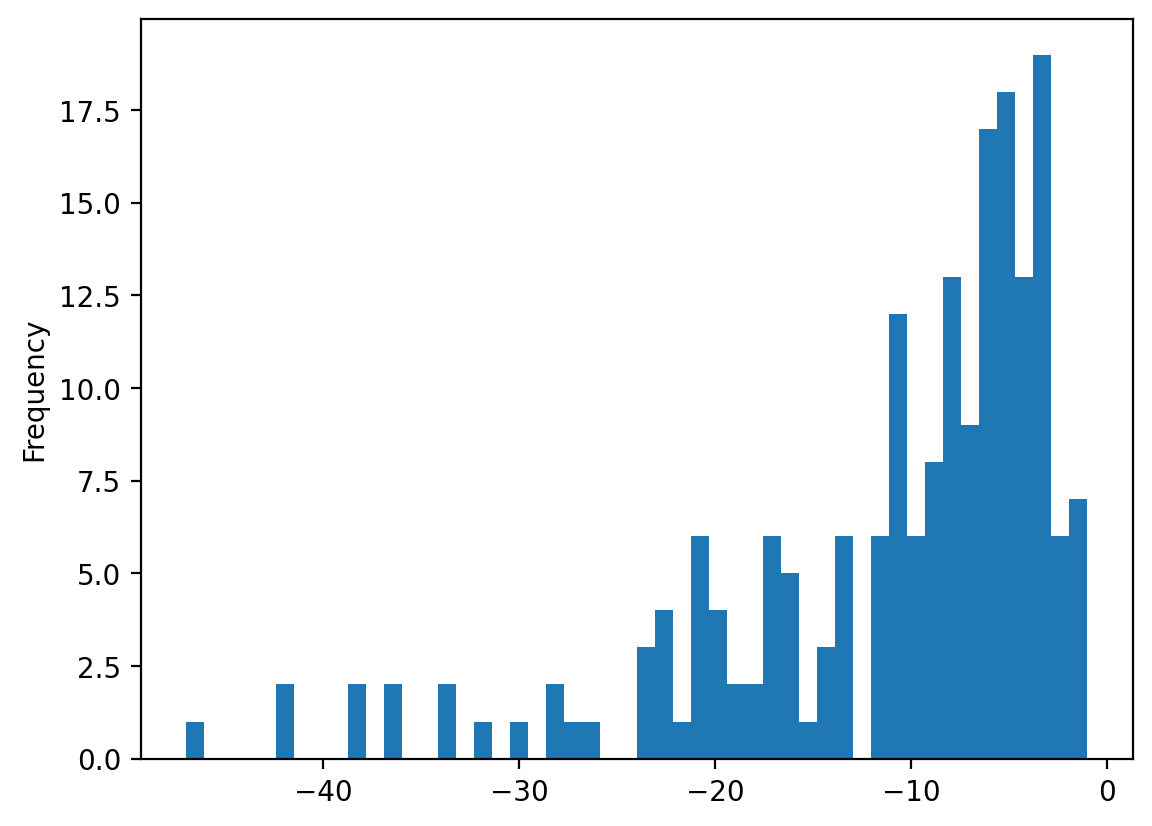

In [69]:
bal_df.loc[
    bal_df.Episode_id.isna()
    & bal_df.prev_episode.eq('none')
    & bal_df.next_episode.eq('VAP')
].next_episode_gap.plot.hist(bins=50)

In [ ]:
def get_patient_superinfection_vap_days(data: pd.DataFrame, patient: int) -> pd.Series:
    IMPRESSIONS = (
        (7, 8),
        (10,),
        (14,)
    )
    data_slice = data.loc[data.patient.eq(patient)]
    super_vap_days = []
    for impression in IMPRESSIONS:
        field = f'Episode_clinical_impression_d{impression[0]}'
        # This is how many days into the future (inclusive)
        # we will look for for a BAL (8 for day 7 adjudications)
        uppercap = impression[-1]
        idx = (
            data_slice[field].str.contains('Super').fillna(False)
            & data_slice.Episode_category.isin(['CAP', 'HAP'])
        )
        for _, row in data_slice.loc[idx].iterrows():
            # Select BAL that prompted Superinfection adjudication
            query = (
                data_slice.day_of_hospitalization.gt(row.day_of_hospitalization)
                & data_slice.day_of_hospitalization.le(row.day_of_hospitalization + uppercap)
                & data_slice.BAL_performed
                & data_slice.Episode_id.eq(row.Episode_id)
            )
            # We take the last BAL if many were found (~5 patients)
            last_bal_prior_to_super = data_slice.loc[query].tail(1)
            if last_bal_prior_to_super.shape[0] == 0:
                print(f'Superinfection BAL not found for {row.bal_barcode}, using day of adjudication')
                vap_date = row.day_of_hospitalization + impression[0]
            else:
                vap_date = last_bal_prior_to_super.day_of_hospitalization[0]
            # For each VAP date, check that day -1 and -2 are intubated
            day_m2 = vap_date - 2
            query = (
                data_slice.day_of_hospitalization.ge(day_m2)
                & data_slice.day_of_hospitalization.lt(vap_date)
            )
            n_intub = data_slice.Intubation_flag[query].sum()
            n_total = query.sum()
            if n_intub < n_total:
                print(f'For episode {row.bal_barcode} superinfection on d{vap_date} has {n_intub}/2 preceding intubated days, skipping')
                continue
            super_vap_days.append(vap_date)
    return data.patient.eq(patient) & data.day_of_hospitalization.isin(super_vap_days)

In [72]:
def get_patient_intraepisode_cures(data: pd.DataFrame, patient: int) -> pd.Series:
    IMPRESSIONS = (
        (7, 8),
        (10,),
        (14,)
    )
    data_slice = data.loc[data.patient.eq(patient)]
    cure_days = []
    for impression in IMPRESSIONS:
        field = f'Episode_clinical_impression_d{impression[0]}'
        # This is how many days into the future (inclusive)
        # we will look for for a BAL (8 for day 7 adjudications)
        uppercap = impression[-1]
        idx = (
            data_slice[field].isin(['Cure', 'Cure,Prophylaxis']).fillna(False)
            & data_slice.Episode_category.isin(['CAP', 'HAP'])
        )
        for _, row in data_slice.loc[idx].iterrows():
            # Select BAL that prompted Superinfection adjudication
            query = (
                data_slice.day_of_hospitalization.gt(row.day_of_hospitalization)
                & data_slice.day_of_hospitalization.le(row.day_of_hospitalization + uppercap)
                & data_slice.BAL_performed
                & data_slice.Episode_id.eq(row.Episode_id)
            )
            # We take the last BAL if many were found (~5 patients)
            last_bal_prior_to_cure = data_slice.loc[query].tail(1)
            if last_bal_prior_to_cure.shape[0] == 0:
                continue
            print(f'Cure BAL found for {row.bal_barcode}')
            cure_date = last_bal_prior_to_cure.day_of_hospitalization[0]
            cure_days.append(cure_date)
    return data.patient.eq(patient) & data.day_of_hospitalization.isin(cure_days)

In [73]:
def create_label(data: pd.DataFrame, label: VAPLabel):
    NAME = label.name
    data[NAME] = -1

    non_viral_only_vaps_idx = ~(data.Episode_category.eq('VAP') & data.Episode_etiology.eq('Viral'))

    for pt in data.patient.unique():
        pt_idx = data.patient.eq(pt)
        # select non-viral VAPs
        pt_vaps_idx = (pt_idx & data.Episode_category.eq('VAP') & non_viral_only_vaps_idx)
        supers = None
        if label.super_is_vap:
            supers = get_patient_superinfection_vap_days(data, pt)
            days_after_supers = pd.Series(False, index=data.index)
            for _, super in data.loc[supers].iterrows():
                days_after_supers |= (
                    data.Episode_id.eq(super.Episode_id)
                    & data.day_of_hospitalization.gt(super.day_of_hospitalization)
                )
            pt_vaps_idx |= supers
        # select negative label days
        pt_neg_idx = (pt_idx & data.Episode_category.eq('NPC'))
        if label.drop_npc_with_fungi:
            pt_neg_idx &= ~data.Episode_NPC_other_infection.isin([
                'PJP',
                'fungal/mucor',
                'blastomycosis',
                'Atypical TB'
            ])
        if label.cure_is_npc:
            pt_neg_idx |= get_patient_intraepisode_cures(data, pt)

        # select viral VAPs
        pt_viral_vaps = data.Episode_id[pt_idx & ~non_viral_only_vaps_idx].unique()

        if label.drop_vvap and pt_viral_vaps.size > 0:
            continue

        # negative labels
        query_neg = None
        for _, npc_ep in data.loc[pt_neg_idx].iterrows():
            npc_dt = npc_ep.day_of_hospitalization
            query = (
                pt_idx
                & data.day_of_hospitalization.ge(npc_dt - label.npc_window_prev)
                & data.day_of_hospitalization.le(npc_dt + label.npc_window_post)
                & data.Intubation_flag.eq(1)
            )
            # pick up only days belonging to the same episodes or
            # days outside of any episode
            allowed_days = (
                data.Episode_id.isna()
                | data.Episode_category.eq('NPC')
            )
            if label.cure_is_npc:
                allowed_days |= data.Episode_id.eq(npc_ep.Episode_id)

            query &= allowed_days & ~data.Episode_NPC_other_infection.isin([
                'PJP',
                'fungal/mucor',
                'blastomycosis',
                'Atypical TB'
            ])

            if label.stop_after_first_vap and pt_vaps_idx.sum() > 0:
                first_vap_dt = data.day_of_hospitalization[pt_vaps_idx].iat[0]
                # this day constraint should block subsequent BALs from getting assigned
                query &= data.day_of_hospitalization.lt(first_vap_dt)
            if query.sum() > 0:
                data.loc[query, NAME] = 0
                if query_neg is None:
                    query_neg = query
                else:
                    # union of days set as negative
                    query_neg |= query

        for _, vap_ep in data.loc[pt_vaps_idx].iterrows():
            vap_dt = vap_ep.day_of_hospitalization
            query = (
                pt_idx
                & data.day_of_hospitalization.ge(vap_dt - label.vap_window_prev)
                & data.day_of_hospitalization.le(vap_dt + label.vap_window_post)
                & data.Intubation_flag.eq(1)
                & ( # skip days inside other VAP episodes with exception of VVAP
                    data.Episode_id.isna()
                    | data.Episode_id.isin(pt_viral_vaps)
                    | data.Episode_id.str.split('/').str[-1].ne('VAP')
                )
            )
            # additionally need to skip CAP/HAP superinfection days
            if label.super_is_vap:
                query &= ~days_after_supers
            if query.sum() > 0:
                data.loc[query, NAME] = 1
            # if we are setting 1 for any day where we set 0, this patient
            # has ambiguous days and we should discard the patient
            if (
                    label.drop_ambiguous
                    and query_neg is not None
                    and ((query & query_neg).sum() > 0)
            ):
                data.loc[pt_idx, NAME] = -1
                break
            # if we are not dropping the ambiguous days, but we have a priority,
            # set this priority
            if (
                    label.ambiguous_priority is not None
                    and query_neg is not None
                    and ((query & query_neg).sum() > 0)
            ):
                data.loc[query & query_neg, NAME] = label.ambiguous_priority
            if label.drop_nonfirst_vaps or label.stop_after_first_vap:
                break

In [ ]:
vap_onset_d7_empirical = VAPLabel(
    name='vap_onset_d7_empirical',
    super_is_vap=True,
    cure_is_npc=True,
    drop_ambiguous=False,
    ambiguous_priority=0,
    npc_window_post=-1,
    npc_window_prev=7,
    vap_window_post=-2,
    vap_window_prev=7,
    drop_vvap=False,
    stop_after_first_vap=False
)

In [ ]:
create_label(data, vap_onset_d7_empirical)

In [77]:
data.vap_onset_d7_empirical.value_counts()

-1    13470
 1     1566
 0      251
Name: vap_onset_d7_empirical, dtype: int64

## 6. Patient aggregations

### Number of BALs

In [84]:
bal_num = data.groupby('patient').BAL_performed.sum()
data['number_of_bals'] = bal_num[data.patient].values

### Number of episodes

We're counting pneumonia episodes

Here we need to account for non-adjudicated patients: they will have no `Episode_category` at all

In [85]:
number_of_adjudications = data.groupby('patient').Episode_category.count()
not_adjudicated = number_of_adjudications.index[number_of_adjudications.eq(0)]

data['number_of_episodes'] = 0
idx = data.Episode_category.isin(['CAP', 'HAP', 'VAP'])
data.loc[idx, 'number_of_episodes'] = 1
number_of_episodes = data.groupby('patient').number_of_episodes.sum()
data.number_of_episodes = number_of_episodes[data.patient].values
data.number_of_episodes = data.number_of_episodes.astype(int)
data.loc[data.patient.isin(not_adjudicated), 'number_of_episodes'] = -1

In [86]:
data.number_of_episodes.value_counts().sort_index()

-1      84
 0    1098
 1    7442
 2    2842
 3    2008
 4     880
 5     675
 6     258
Name: number_of_episodes, dtype: int64

### Total pathogens

Aggregate all pathogens across multiple patient BALs, report their identities and number

In [87]:
def collect_pathogens(patient_df):
    idx = patient_df.BAL_performed
    is_na = True
    result = set()
    for _, val in patient_df.pathogen_groups[idx].items():
        if val == 'NA':
            continue
        is_na = False
        if val == 'pathogen-negative':
            continue
        for path in val.split('; '):
            result.add(path)
    if is_na:
        return 'NA', -1
    if len(result) == 0:
        return 'pathogen-negative', 0
    return '; '.join(sorted(result)), len(result)
total_pathogens = data.groupby('patient').apply(collect_pathogens)[data.patient]
data['total_pathogens'] = total_pathogens.str[0].values
data['number_of_total_pathogens'] = total_pathogens.str[1].values

## 7. Previous episodes

### Find previous episode
This is like episode_type but shifted by 1 episode

In [88]:
def set_previous_episode_type(patient_df):
    result = []
    # This is episode ID of the previous day
    prev_id = None
    # This is episode of the previous day
    prev = 'none'
    # This is previous episode
    #    I.e. current day is VAP episode
    #    so it should be filled with episode before the
    #    current VAP episode
    prev_prev = 'none'
    for i, row in patient_df.iterrows():
        # If we see that current row has new episode id
        #     compared to previous day episode,
        #     then we set prev_prev to value of the
        #     previous day episode
        if ((prev_id is None
                and not pd.isnull(row.Episode_id))
             or (prev_id is not None
                     and prev_id != row.Episode_id)):
            # Ignore new nan episodes or `none` episodes
            #    It just means we continue current episode
            if not pd.isnull(prev) and not prev == 'none':
                prev_prev = prev
            prev = row.episode_type
        result.append(prev_prev)
        prev_id = row.Episode_id
        if pd.isnull(prev_id):
            prev_id = None
    return pd.Series(result, index=patient_df.index)
data['prev_episode_type'] = data.groupby('patient').apply(set_previous_episode_type).droplevel(0)

In [89]:
def set_previous_episode_id(patient_df):
    result = []
    # This is episode ID of the previous day
    prev_id = None
    # This is episode of the previous day
    prev = 'none'
    # This is previous episode
    #    I.e. current day is VAP episode
    #    so it should be filled with episode before the
    #    current VAP episode
    prev_prev = 'none'
    for i, row in patient_df.iterrows():
        # If we see that current row has new episode id
        #     compared to previous day episode,
        #     then we set prev_prev to value of the
        #     previous day episode
        if ((prev_id is None
                and not pd.isnull(row.Episode_id))
             or (prev_id is not None
                     and prev_id != row.Episode_id)):
            # Ignore new nan episodes
            #    It just means we continue current episode
            if not pd.isnull(prev):
                prev_prev = prev
            prev = row.Episode_id
        result.append(prev_prev)
        prev_id = row.Episode_id
        if pd.isnull(prev_id):
            prev_id = None
    return pd.Series(result, index=patient_df.index)
data['prev_episode_id'] = data.groupby('patient').apply(set_previous_episode_id).droplevel(0)

In [90]:
data.loc[data.prev_episode_id.isin(viral_vap_ids), 'prev_episode_type'] = 'VVAP'

In [91]:
data.prev_episode_type.value_counts()

none    7084
VAP     3786
HAP     2008
NPC      997
CAP      861
VVAP     551
Name: prev_episode_type, dtype: int64

### First episode

In [92]:
patient_first_episode = data.loc[
    data.episode_type.notna()
].groupby('patient').head(1).set_index('patient')

In [93]:
idx = data.patient.isin(patient_first_episode.index)
data.loc[idx, 'first_episode_id'] = patient_first_episode.Episode_id[data.patient[idx]].values
data.loc[idx, 'first_episode_type'] = patient_first_episode.episode_type[data.patient[idx]].values

In [94]:
data.loc[data.first_episode_id.isin(viral_vap_ids), 'first_episode_type'] = 'VVAP'

Clear `first_episode_type` for the first episode itself

In [95]:
data.loc[data.Episode_id.eq(data.first_episode_id), 'first_episode_type'] = 'none'

In [96]:
data.first_episode_type.fillna('none', inplace=True)

In [97]:
data.first_episode_type.value_counts()

none    13846
CAP       540
HAP       418
VVAP      235
NPC       158
VAP        90
Name: first_episode_type, dtype: int64

### First pathogen

In [98]:
data.loc[data.BAL_performed].groupby('patient').head(1).shape

(690, 145)

In [99]:
patient_first_pathogen = (
    data.loc[data.BAL_performed].groupby('patient').head(1).set_index('patient').pathogen_groups
)

In [100]:
data['first_pathogen'] = 'NA'
idx = data.patient.isin(patient_first_pathogen.index)
data.loc[idx, 'first_pathogen'] = patient_first_pathogen[data.patient[idx]].values

In [101]:
data.first_pathogen.value_counts()

pathogen-negative                                            5228
SARS-CoV-2                                                   3879
SARS-CoV-2; Gram+                                            1386
Gram+                                                        1364
Gram-*                                                        811
Other viruses                                                 593
Gram-*; Gram+                                                 461
Gram-*; SARS-CoV-2; Gram+                                     263
Pseudomonas aeruginosa                                        229
Gram-*; SARS-CoV-2                                            206
Gram-*; Pseudomonas aeruginosa                                152
Pseudomonas aeruginosa; Gram+                                 135
Other viruses; Gram+                                          133
NA                                                            121
Gram-*; Other viruses                                          96
Pseudomona

### Previous pathogen

We repeat the procedure for the current pathogen:
1. Set new field to `NA`
2. Set dates of BAL to BAL pathogens
3. Set cured episode ends to pathogen-negative
4. Set viral pathogens to negative for viral retest fields
5. Forward fill within patient + ICU stay

But before the forward fill we shift not NA values within patient and episode

In [102]:
data['prev_pathogen_groups'] = 'NA'
data.loc[data.BAL_performed, 'prev_pathogen_groups'] = bal_pathogens_final.values

In [103]:
bal_pathogens_final.values

array(['Gram-*', 'Gram-*', 'group2_Gram+', ..., 'pathogen-negative',
       'pathogen-negative', 'group2_Gram+'], dtype=object)

In [104]:
idx = data.Episode_duration.notna() & data.Episode_is_cured.eq('Cured')
for i, row in data.loc[idx].iterrows():
    try:
        target_idx = data.index[int(data.index.get_loc(i) + row.Episode_duration)]
    except:
        continue
    target_row = data.loc[target_idx]
    if (row.patient == target_row.patient
            and row.ICU_stay == target_row.ICU_stay
            and target_row.prev_pathogen_groups == 'NA'):
        data.loc[target_idx, 'prev_pathogen_groups'] = 'pathogen-negative'

In [ ]:
def preffill_prev_pathogens(patient_stay_df):
    result = []
    prev = 'NA'
    virus_cleared = None
    for _, row in patient_stay_df.iterrows():
        cur = 'NA'
        # Current BAL has priority
        if row.BAL_performed and row.pathogen_groups != 'NA':
            prev = row.pathogen_groups
            cur = prev
        result.append(cur)
    return pd.Series(result, index=patient_stay_df.index)
# here groupby resorts rows, so we cannot just assign with `.values`
# we need to match by index
# prev_pathogen_groups = data.groupby(['patient', 'ICU_stay']).apply(preffill_prev_pathogens)
# prev_pathogen_groups.index = prev_pathogen_groups.index.droplevel(0)
# prev_pathogen_groups.index = prev_pathogen_groups.index.droplevel(0)
# data.prev_pathogen_groups = prev_pathogen_groups
data.prev_pathogen_groups = data.groupby(['patient', 'ICU_stay']).apply(preffill_prev_pathogens).values

In [106]:
idx = data.prev_pathogen_groups.ne('NA')
data.loc[idx, 'prev_pathogen_groups'] = data.loc[idx].groupby(['patient', 'ICU_stay']).prev_pathogen_groups.shift()

In [107]:
idx = data.prev_pathogen_groups.eq('NA')
data.loc[idx, 'prev_pathogen_groups'] = np.nan

In [108]:
data.prev_pathogen_groups = data.groupby(['patient', 'ICU_stay']).prev_pathogen_groups.ffill()

In [109]:
data.prev_pathogen_groups.fillna('NA', inplace=True)

In [110]:
data.prev_pathogen_groups.value_counts()

NA                                                           7110
pathogen-negative                                            2558
SARS-CoV-2                                                   1406
Gram-*                                                        810
Gram+                                                         807
SARS-CoV-2; Gram+                                             736
Gram-*; Gram+                                                 411
Pseudomonas aeruginosa                                        323
Other viruses                                                 250
Gram-*; SARS-CoV-2                                            191
Gram-*; SARS-CoV-2; Gram+                                     143
Gram-*; Pseudomonas aeruginosa                                131
Pseudomonas aeruginosa; Gram+                                 101
Pseudomonas aeruginosa; SARS-CoV-2                             81
Other viruses; Gram+                                           49
Gram-*; Ot

## 8. Prepare output

Now, prepare the output dataframe

In [116]:
data.loc[data.BAL_pct_neutrophils.notna(), 'neutrophils'] = data.BAL_pct_neutrophils.ge(50).astype(int)
data.neutrophils.fillna(-1, inplace=True)
data.neutrophils = data.neutrophils.astype(int)

In [ ]:
COLUMNS_OF_INTEREST = [
    'patient',
    'Patient_id',
    'ICU_stay',
    'ICU_day',
    'Episode_id',
    'bal_barcode',
    'Binary_outcome',
    'Discharge_disposition',
    'Episode_etiology',
    'Immunocompromised_flag',
    'External_transfer_flag',
    'Episode_NPC_other_infection',
    'SOFA_score',

    'pathogen_groups',
    'clear_cut',
    'number_of_pathogens',
    'episode_type',
    'clinical_opinion_l2',
    'day_of_hospitalization',
    'week_of_hospitalization',
    'days_on_ventilator',
    'day_since_first_intubation',
    'mean_nat_score_until_yesterday',
    'episode_counter',
    'future_episode_outcome',
    'is_episode_cured',
    'vap_onset_d7_empirical',
    'number_of_bals',
    'number_of_episodes',
    'total_pathogens',
    'number_of_total_pathogens',
    'prev_episode_type',
    'prev_episode_id',
    'first_episode_type',
    'first_pathogen',
    'prev_pathogen_groups',
    'neutrophils',

    'RASS_score_binned',
    'GCS_verbal_response_binned',
    'GCS_motor_response_binned',
    'GCS_eye_opening_binned',

    # Additional numerical covariates
    'Age',
    'BMI',
    'GSC_score',
    'Driving_pressure',
    'Procalcitonin_ff',
    'D_dimer_ff',
    'LDH_ff',
    'Cumulative_vent_changes',
    'days_of_icu_abx_until_today',
    'cumulative_icu_steroid_dose_until_today',
]

In [118]:
for c in COLUMNS_OF_INTEREST:
    if c not in data.columns:
        print(c)

In [119]:
labels = data.loc[:, COLUMNS_OF_INTEREST].copy()

### Add grouping variables for NPC

NPC group:
1. Find infected NPC samples
2. Mark days that recieved pathogen from them as infected NPC
3. Find pathogen-negative NPC samples
4. Mark days that recieved pathogen from them as NPC
5. Mark NA days before NPC as NPC

In [120]:
npc_with_fungi = labels.Episode_id[labels.Episode_NPC_other_infection.isin([
    'PJP',
    'fungal/mucor',
    'blastomycosis',
    'Atypical TB'
])]

In [121]:
labels['is_npc_with_fungi'] = False
for npc_ep_with_fungi in npc_with_fungi:
    idx = labels.Episode_id.eq(npc_ep_with_fungi)
    npc_pt = labels.patient[idx].values[0]
    npc_dt = labels.day_of_hospitalization[idx].values[0]
    next_ep = labels.patient.eq(npc_pt) & labels.day_of_hospitalization.gt(npc_dt) & labels.Episode_id.notna()
    npc_label_idx = labels.prev_episode_id.eq(npc_ep_with_fungi)
    if next_ep.sum() > 0:
        next_ep_dt = labels.day_of_hospitalization[next_ep].values[0]
        npc_label_idx &= labels.day_of_hospitalization.lt(next_ep_dt)
    npc_label_idx |= labels.Episode_id.eq(npc_ep_with_fungi)
    labels.loc[npc_label_idx, 'is_npc_with_fungi'] = True

In [122]:
idx = (
    labels.episode_type.eq('NPC')
    & labels.pathogen_groups.eq('pathogen-negative')
    & ~labels.is_npc_with_fungi
)
npc_controls = labels.Episode_id[idx]

We can set days between admission and pathogen-negative NPC as `npc_control`.
To do that we check that the `prev_episode_type='none'`

In [123]:
labels['is_npc_control'] = False
for npc_ep in npc_controls:
    idx = labels.Episode_id.eq(npc_ep)
    npc_pt = labels.patient[idx].values[0]
    npc_dt = labels.day_of_hospitalization[idx].values[0]
    next_ep = labels.patient.eq(npc_pt) & labels.day_of_hospitalization.gt(npc_dt) & labels.Episode_id.notna()
    # label into the future until next episode
    npc_label_idx = labels.prev_episode_id.eq(npc_ep)
    if next_ep.sum() > 0:
        next_ep_dt = labels.day_of_hospitalization[next_ep].values[0]
        npc_label_idx &= labels.day_of_hospitalization.lt(next_ep_dt)
    npc_label_idx |= labels.Episode_id.eq(npc_ep)
    labels.loc[npc_label_idx, 'is_npc_control'] = True
    # label into the past until admission
    idx = (
        labels.patient.eq(npc_pt)
        & labels.day_of_hospitalization.lt(npc_dt)
        & labels.prev_episode_type.eq('none')
    )
    labels.loc[idx, 'is_npc_control'] = True

In [124]:
labels.is_npc_control.value_counts()

False    14160
True      1127
Name: is_npc_control, dtype: int64

**Culture-negative pneumonia group**

We select pathogen-negative pneumonias and from them select pathogen-negative days before any pathogen detected

In [125]:
idx = (
    labels.episode_type.isin(['CAP', 'HAP', 'VAP', 'VVAP'])
    & labels.pathogen_groups.eq('pathogen-negative')
)
cul_neg_eps = labels.Episode_id[idx].unique()

In [ ]:
labels['is_culture_negative_pneumonia'] = False
for ep in cul_neg_eps:
    idx = labels.Episode_id.eq(ep)
    non_neg_idx = idx & ~labels.pathogen_groups.isin(['NA', 'pathogen-negative'])
    if non_neg_idx.sum() > 0:
        first_non_neg_day = labels.day_of_hospitalization[non_neg_idx].iloc[0]
        idx &= labels.day_of_hospitalization.lt(first_non_neg_day)
    if idx.sum() == 0:
        print(f'Skipping {ep}, first day is pathogen positive')
        continue
    labels.loc[idx, 'is_culture_negative_pneumonia'] = True

In [127]:
labels.is_culture_negative_pneumonia.value_counts()

False    14220
True      1067
Name: is_culture_negative_pneumonia, dtype: int64

**Select perturbation for pathogens**:
* take only BALs from adjudicated episodes

In [128]:
idx = (
    ~labels.pathogen_groups.isin(['pathogen-negative', 'NA'])
    & labels.episode_type.isin(['CAP', 'HAP', 'VAP', 'VVAP'])
)
labels.loc[idx, 'perturbation_groups'] = labels.pathogen_groups[idx]
labels.loc[labels.is_npc_control, 'perturbation_groups'] = 'NPC'
labels.perturbation_groups.fillna('discard', inplace=True)

In [129]:
labels.perturbation_groups.value_counts()

discard                                                      9483
NPC                                                          1127
Gram-*                                                        852
SARS-CoV-2                                                    816
Gram+                                                         691
SARS-CoV-2; Gram+                                             494
Gram-*; Gram+                                                 389
Pseudomonas aeruginosa                                        339
Gram-*; SARS-CoV-2                                            229
Other viruses                                                 157
Gram-*; SARS-CoV-2; Gram+                                     125
Pseudomonas aeruginosa; Gram+                                 115
Pseudomonas aeruginosa; SARS-CoV-2                            107
Gram-*; Pseudomonas aeruginosa                                 99
Gram-*; Other viruses                                          44
Other viru

**Split early & late SARS-CoV-2**
* based on days_on_ventilator <= 2
* split `SARS-CoV-2` group and `SARS-CoV-2; Gram+` group

In [130]:
labels['perturbation_groups_2'] = labels.perturbation_groups.copy()

In [131]:
labels.loc[
    labels.perturbation_groups_2.eq('SARS-CoV-2')
    & labels.days_on_ventilator.le(2),
    'perturbation_groups_2'
] = 'Early SARS-CoV-2'
labels.perturbation_groups_2 = labels.perturbation_groups_2.replace({
    'SARS-CoV-2': 'Late SARS-CoV-2'
})

In [132]:
labels.loc[
    labels.perturbation_groups_2.eq('SARS-CoV-2; Gram+')
    & labels.days_on_ventilator.le(2),
    'perturbation_groups_2'
] = 'Early SARS-CoV-2; Gram+'
labels.perturbation_groups_2 = labels.perturbation_groups_2.replace({
    'SARS-CoV-2; Gram+': 'Late SARS-CoV-2; Gram+'
})

### Add single-cell info

In [ ]:
sc_libraries = pd.read_csv(common_data.SC_LIBRARIES)
sc_script = sc_libraries.loc[sc_libraries.name.eq('SCRIPT')].copy()

In [133]:
sc_labels = labels[labels.bal_barcode.isin(sc_script.individual)].copy()

In [134]:
sc_labels['cohort'] = 'SCRIPT'

In [135]:
other_bals = sc_libraries.loc[sc_libraries.name.ne('SCRIPT'), ['name', 'individual']].copy()

In [136]:
other_bals = other_bals.drop_duplicates()

In [138]:
other_bals.rename(columns={'name': 'cohort', 'individual': 'bal_barcode'}, inplace=True)

In [139]:
idx = other_bals.cohort.eq('Healthy control')
other_bals.loc[idx, 'episode_type'] = 'none'
other_bals.loc[idx, 'pathogen_groups'] = 'pathogen-negative'
other_bals.loc[idx, 'clear_cut'] = True
other_bals.loc[idx, 'prev_episode_type'] = 'none'
other_bals.loc[idx, 'first_episode_type'] = 'none'

### Add Age and BMI info from tables from PASC paper

In [ ]:
sc_to_pasc_ids = pd.read_excel(common_data.PASC_MAPPING)

In [ ]:
healthy_volunteer_meta = pd.read_excel(common_data.HEALTHY_META)

In [142]:
sc_to_pasc_ids = sc_to_pasc_ids.merge(
    healthy_volunteer_meta[['Study ID', 'Age', 'BMI']],
    left_on='Deidentified Subject ID',
    right_on='Study ID',
    how='left'
)

In [144]:
sc_to_pasc_ids = sc_to_pasc_ids.set_index('Subject ID')

In [145]:
idx = other_bals.cohort.eq('Healthy control')
other_bals.loc[idx, 'Age'] = sc_to_pasc_ids.loc[other_bals.bal_barcode[idx]].Age.values
other_bals.loc[idx, 'BMI'] = sc_to_pasc_ids.loc[other_bals.bal_barcode[idx]].BMI.values

In [146]:
sc_labels.shape

(263, 58)

In [147]:
sc_labels = pd.concat([sc_labels, other_bals], axis=0)

In [148]:
sc_labels.shape

(301, 58)

In [149]:
idx = sc_labels.patient.notna()
sc_labels.loc[idx, 'patient_str'] = sc_labels.patient[idx].astype(int).astype(str)

In [150]:
idx = sc_labels.patient.isna()
sc_labels.loc[idx, 'patient_str'] = sc_labels.bal_barcode[idx]

/tmp/ipykernel_803676/1472065517.py:2: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  sc_labels.loc[idx, 'patient_str'] = sc_labels.bal_barcode[idx]


In [152]:
sc_labels.drop(columns='patient', inplace=True)
sc_labels.rename(columns={'patient_str': 'patient'}, inplace=True)

In [153]:
labels.patient = labels.patient.astype(str)

### Create grouping variables

In [154]:
sc_labels['is_healthy_control'] = sc_labels.cohort.eq('Healthy control')

In [ ]:
sc_labels['is_long_covid'] = sc_labels.cohort.eq('PASC')

In [156]:
sc_labels.is_healthy_control.sum()

9

In [157]:
sc_labels.is_npc_control.sum()

26

In [158]:
sc_labels.is_culture_negative_pneumonia.sum()

32

In [159]:
sc_labels.is_long_covid.sum()

25

Select perturbation for pathogens:
* take only BALs from adjudicated episodes ?
* this will exclude episodes without duration (check how many?)

In [160]:
sc_labels.loc[sc_labels.is_healthy_control, 'perturbation_groups'] = 'Healthy'
sc_labels.loc[sc_labels.is_healthy_control, 'perturbation_groups_2'] = 'Healthy'
sc_labels.perturbation_groups.fillna('discard', inplace=True)
sc_labels.perturbation_groups_2.fillna('discard', inplace=True)

In [161]:
sc_labels.perturbation_groups.value_counts()

discard                                  93
SARS-CoV-2                               60
NPC                                      26
SARS-CoV-2; Gram+                        24
Gram+                                    23
Gram-*                                   15
Pseudomonas aeruginosa                   11
Pseudomonas aeruginosa; SARS-CoV-2        9
Gram-*; Gram+                             9
Healthy                                   9
Gram-*; SARS-CoV-2                        6
Gram-*; SARS-CoV-2; Gram+                 5
Other viruses                             4
Gram-*; Pseudomonas aeruginosa            3
Pseudomonas aeruginosa; Gram+             2
Other viruses; Pseudomonas aeruginosa     1
Gram-*; Other viruses; SARS-CoV-2         1
Name: perturbation_groups, dtype: int64

In [162]:
sc_labels.perturbation_groups_2.value_counts()

discard                                  93
Early SARS-CoV-2                         35
NPC                                      26
Late SARS-CoV-2                          25
Gram+                                    23
Late SARS-CoV-2; Gram+                   16
Gram-*                                   15
Pseudomonas aeruginosa                   11
Healthy                                   9
Gram-*; Gram+                             9
Pseudomonas aeruginosa; SARS-CoV-2        9
Early SARS-CoV-2; Gram+                   8
Gram-*; SARS-CoV-2                        6
Gram-*; SARS-CoV-2; Gram+                 5
Other viruses                             4
Gram-*; Pseudomonas aeruginosa            3
Pseudomonas aeruginosa; Gram+             2
Other viruses; Pseudomonas aeruginosa     1
Gram-*; Other viruses; SARS-CoV-2         1
Name: perturbation_groups_2, dtype: int64

In [163]:
n_bals_per_group = sc_labels.perturbation_groups.value_counts()
discard = n_bals_per_group.index[n_bals_per_group < 8]
sc_labels.loc[sc_labels.perturbation_groups.isin(discard), 'perturbation_groups'] = 'discard'
labels.loc[
    ~labels.perturbation_groups.isin(sc_labels.perturbation_groups.unique()),
    'perturbation_groups'
] = 'discard'

In [164]:
n_bals_per_group = sc_labels.perturbation_groups_2.value_counts()
discard = n_bals_per_group.index[n_bals_per_group < 8]
sc_labels.loc[sc_labels.perturbation_groups_2.isin(discard), 'perturbation_groups_2'] = 'discard'
labels.loc[
    ~labels.perturbation_groups_2.isin(sc_labels.perturbation_groups_2.unique()),
    'perturbation_groups_2'
] = 'discard'

In [165]:
labels['general_perturbation_group'] = 'Pathogen'
idx = labels.perturbation_groups.isin(['Healthy', 'NPC', 'discard'])
labels.loc[
    idx,
    'general_perturbation_group'
] = labels.perturbation_groups[idx].astype(str)
labels.general_perturbation_group = pd.Categorical(
    labels.general_perturbation_group,
    categories=['Healthy', 'NPC', 'Pathogen', 'discard']
)

In [166]:
sc_labels['general_perturbation_group'] = 'Pathogen'
idx = sc_labels.perturbation_groups.isin(['Healthy', 'NPC', 'discard'])
sc_labels.loc[
    idx,
    'general_perturbation_group'
] = sc_labels.perturbation_groups[idx].astype(str)
sc_labels.general_perturbation_group = pd.Categorical(
    sc_labels.general_perturbation_group,
    categories=['Healthy', 'NPC', 'Pathogen', 'discard']
)

In [167]:
sc_labels.perturbation_groups.value_counts()

discard                               115
SARS-CoV-2                             60
NPC                                    26
SARS-CoV-2; Gram+                      24
Gram+                                  23
Gram-*                                 15
Pseudomonas aeruginosa                 11
Pseudomonas aeruginosa; SARS-CoV-2      9
Gram-*; Gram+                           9
Healthy                                 9
Name: perturbation_groups, dtype: int64

In [168]:
sc_labels.perturbation_groups_2.value_counts()

discard                               115
Early SARS-CoV-2                       35
NPC                                    26
Late SARS-CoV-2                        25
Gram+                                  23
Late SARS-CoV-2; Gram+                 16
Gram-*                                 15
Pseudomonas aeruginosa                 11
Pseudomonas aeruginosa; SARS-CoV-2      9
Gram-*; Gram+                           9
Healthy                                 9
Early SARS-CoV-2; Gram+                 8
Name: perturbation_groups_2, dtype: int64

In [169]:
sc_labels.general_perturbation_group.value_counts()

Pathogen    151
discard     115
NPC          26
Healthy       9
Name: general_perturbation_group, dtype: int64

In [170]:
labels.perturbation_groups.value_counts()

discard                               10472
NPC                                    1127
Gram-*                                  852
SARS-CoV-2                              816
Gram+                                   691
SARS-CoV-2; Gram+                       494
Gram-*; Gram+                           389
Pseudomonas aeruginosa                  339
Pseudomonas aeruginosa; SARS-CoV-2      107
Name: perturbation_groups, dtype: int64

In [171]:
labels.perturbation_groups_2.value_counts()

discard                               10472
NPC                                    1127
Gram-*                                  852
Late SARS-CoV-2                         697
Gram+                                   691
Late SARS-CoV-2; Gram+                  449
Gram-*; Gram+                           389
Pseudomonas aeruginosa                  339
Early SARS-CoV-2                        119
Pseudomonas aeruginosa; SARS-CoV-2      107
Early SARS-CoV-2; Gram+                  45
Name: perturbation_groups_2, dtype: int64

In [172]:
labels.general_perturbation_group.value_counts()

discard     10472
Pathogen     3688
NPC          1127
Healthy         0
Name: general_perturbation_group, dtype: int64

In [173]:
sc_labels.is_episode_cured.value_counts()

-1.0    222
 0.0     22
 1.0     19
Name: is_episode_cured, dtype: int64

In [174]:
sc_labels.vap_onset_d7_empirical.value_counts()

-1.0    234
 1.0     25
 0.0      4
Name: vap_onset_d7_empirical, dtype: int64

## 9. Train/test split

Need to split these labels:
* perturbation_groups_2
* viral_vs_bacterial
* is_episode_cured
* vap_onset_d7_empirical

In [175]:
VIRAL = ['Early SARS-CoV-2']
BACTERIAL = ['Gram-*', 'Gram+', 'Pseudomonas aeruginosa', 'Gram-*; Gram+']

In [176]:
labels['viral_vs_bacterial'] = -1
labels.loc[labels.perturbation_groups_2.isin(
   VIRAL
), 'viral_vs_bacterial'] = 0
labels.loc[labels.perturbation_groups_2.isin(
    BACTERIAL
), 'viral_vs_bacterial'] = 1
labels.viral_vs_bacterial.value_counts(dropna=False)

-1    12897
 1     2271
 0      119
Name: viral_vs_bacterial, dtype: int64

In [177]:
sc_labels['viral_vs_bacterial'] = -1
sc_labels.loc[sc_labels.perturbation_groups_2.isin(
   VIRAL
), 'viral_vs_bacterial'] = 0
sc_labels.loc[sc_labels.perturbation_groups_2.isin(
    BACTERIAL
), 'viral_vs_bacterial'] = 1
sc_labels.viral_vs_bacterial.value_counts(dropna=False)

-1    208
 1     58
 0     35
Name: viral_vs_bacterial, dtype: int64

In [178]:
def add_train_test_split(
        data: pd.DataFrame,
        label: str,
        ignore_labels: tuple,
        stratify_by: str,
        split_col_prefix: str,
        test_patients: typing.Optional[list] = None,
        n_folds: int = 4,
        test_fraction: float = 0.22,
        random_seed: int = 123,
):
    TEST_PROB = test_fraction
    rng = np.random.default_rng(seed=random_seed)
    label_col = data[label]
    stratify_col = data[stratify_by]

    test_patients_needed = {}
    for l in label_col.unique():
        if l in ignore_labels:
            continue
        n_patients = stratify_col[label_col.eq(l)].nunique()
        n_test_patients = round(n_patients * TEST_PROB)
        test_patients_needed[l] = n_test_patients

    already_test_pts = set()
    # for _ in range(n_folds):
    #     already_test_pts.append(set())

    if test_patients is None:
        test_patients = []
        for _ in range(n_folds):
            test_patients.append(collections.defaultdict(set))
    else:
        test_patients = copy.deepcopy(test_patients)
        # the definition of multilabel patient might have changes
        # so let's update the labels here
        for i in range(n_folds):
            for pts in test_patients[i].values():
                already_test_pts.update(pts)
                for pt in pts:
                    for l in label_col[stratify_col.eq(pt)].unique():
                        if l in ignore_labels:
                            continue
                        test_patients[i][l].add(pt)

    n_labels_per_pt = data.loc[~label_col.isin(ignore_labels)].groupby(stratify_by)[label].nunique()
    pts_with_mult_labels = list(n_labels_per_pt.index[n_labels_per_pt.gt(1)])
    pts_with_mult_labels = list(set(pts_with_mult_labels) - already_test_pts)
    pts_with_mult_labels = sorted(pts_with_mult_labels)

    rng.shuffle(pts_with_mult_labels)

    n_mult_label_pts = round(len(pts_with_mult_labels) * TEST_PROB)
    for i in range(n_folds):
        for pt in pts_with_mult_labels[i * n_mult_label_pts:(i + 1) * n_mult_label_pts]:
            adding = True
            for l in label_col[stratify_col.eq(pt)].unique():
                if l in ignore_labels:
                    continue
                if len(test_patients[i][l]) >= test_patients_needed[l]:
                    adding = False
            if adding:
                for l in label_col[stratify_col.eq(pt)].unique():
                    if l in ignore_labels:
                        continue
                    test_patients[i][l].add(pt)

    for l in label_col.unique():
        if l in ignore_labels:
            continue
        patients = stratify_col[label_col.eq(l)].unique()
        patients = list(set(patients) - set(pts_with_mult_labels))
        patients = list(set(patients) - already_test_pts)
        patients = sorted(patients)
        rng.shuffle(patients)
        offset = 0
        for i in range(n_folds):
            n_remaining = test_patients_needed[l] - len(test_patients[i][l])
            if n_remaining > 0:
                test_patients[i][l].update(patients[offset:offset + n_remaining])
            data.loc[label_col.eq(l), f'{split_col_prefix}_{i + 1}'] = 'train'
            data.loc[
                (
                    label_col.eq(l)
                    & stratify_col.isin(test_patients[i][l])
                ),
                f'{split_col_prefix}_{i + 1}'
            ] = 'test'
            offset += n_remaining
    return test_patients

In [179]:
def check_splits(
        data: pd.DataFrame,
        col_prefix: str,
):
    for col in data.columns:
        if col_prefix not in col:
            continue
        train_pts = set(data.patient[data[col].eq('train')])
        test_pts = set(data.patient[data[col].eq('test')])
        overlap = len(train_pts & test_pts)
        if overlap > 0:
            print(f'{col}: {overlap} patients in both train and test')
    for i, j in itertools.combinations(range(4), r=2):
        test_pts_1 = set(data.patient[data[f'{col_prefix}_{i + 1}'].eq('test')])
        test_pts_2 = set(data.patient[data[f'{col_prefix}_{j + 1}'].eq('test')])
        overlap = len(test_pts_1 & test_pts_2)
        if overlap > 0:
            print(f'split {i + 1} and {j + 1}: {overlap} common patients ({test_pts_1 & test_pts_2})')

def check_splits_2(
        data_larger: pd.DataFrame,
        data_smaller: pd.DataFrame,
        col_prefix: str
):
    for col in data.columns:
        if col_prefix not in col:
            continue
        larger_pts = set(data_larger.patient[data_larger[col].eq('test')])
        smaller_pts = set(data_smaller.patient[data_smaller[col].eq('test')])
        unique_smaller = smaller_pts - larger_pts
        unique_larger = larger_pts - smaller_pts
        if len(unique_smaller) > 0:
            print(f'{col}: {len(unique_smaller)} patients only in small')
        if len(unique_larger) == 0:
            print(f'{col}: larger does not have any extra patients')

def get_split_stats(data: pd.DataFrame, label: str, ignore_labels: tuple, split_col_prefix: str):
    result = []
    for l in data[label].unique():
        if l in ignore_labels:
            continue
        n_pts = data.patient[data[label].eq(l)].nunique()
        n_test_pts = []
        for i in range(4):
            n_test_pts.append(data.patient[
                data[label].eq(l)
                & data[f'{split_col_prefix}_{i + 1}'].eq('test')
            ].nunique())
        result.append([l] + list(np.array(n_test_pts) / n_pts))
    colnames = ['label'] + [f'{split_col_prefix}_{i + 1}' for i in range(4)]
    result = pd.DataFrame(result, columns=colnames)
    return result

def get_split_stats_for_labels(data: pd.DataFrame, label: str, ignore_labels: tuple, split_col_prefix: str):
    result = []
    idx = ~data[label].isin(ignore_labels)
    result = pd.DataFrame(
        index=data[label][idx].unique(),
        columns=['overall'] + list(itertools.chain(*[
            (f'split_{i + 1}_train', f'split_{i + 1}_test') for i in range(4)
        ]))
    )
    result['overall'] = data[label][idx].value_counts() / idx.sum()
    for i in range(4):
        idx_train = data[f'{split_col_prefix}_{i + 1}'].eq('train') & idx
        idx_test = data[f'{split_col_prefix}_{i + 1}'].eq('test') & idx
        result[f'split_{i + 1}_train'] = data[label][idx_train].value_counts() / idx_train.sum()
        result[f'split_{i + 1}_test'] = data[label][idx_test].value_counts() / idx_test.sum()
    return result

In [180]:
pg2_sc_test_pts = add_train_test_split(
    data=sc_labels,
    label='perturbation_groups_2',
    ignore_labels=('discard',),
    stratify_by='patient',
    split_col_prefix='test_split_pg2_split',
    random_seed=978451
)
add_train_test_split(
    data=labels,
    label='perturbation_groups_2',
    ignore_labels=('discard',),
    stratify_by='patient',
    split_col_prefix='test_split_pg2_split',
    test_patients=pg2_sc_test_pts,
    random_seed=123472
);

In [181]:
check_splits(sc_labels, 'test_split_pg2_split')
check_splits(labels, 'test_split_pg2_split')
check_splits_2(labels, sc_labels, 'test_split_pg2_split')

In [182]:
get_split_stats(sc_labels, 'perturbation_groups_2', ('discard',), 'test_split_pg2_split').round(2)

,label,test_split_pg2_split_1,test_split_pg2_split_2,test_split_pg2_split_3,test_split_pg2_split_4
0,Gram-*,0.23,0.23,0.23,0.23
1,Late SARS-CoV-2; Gram+,0.20,0.20,0.20,0.20
2,Early SARS-CoV-2; Gram+,0.25,0.25,0.25,0.25
3,Early SARS-CoV-2,0.23,0.23,0.23,0.23
4,Late SARS-CoV-2,0.21,0.21,0.21,0.21
5,NPC,0.21,0.21,0.21,0.21
6,Pseudomonas aeruginosa; SARS-CoV-2,0.29,0.14,0.29,0.29
7,Gram+,0.20,0.20,0.20,0.20
8,Gram-*; Gram+,0.22,0.22,0.22,0.22
9,Pseudomonas aeruginosa,0.22,0.22,0.22,0.22


In [183]:
get_split_stats_for_labels(sc_labels, 'perturbation_groups_2', ('discard',), 'test_split_pg2_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
Gram-*,0.08,0.08,0.07,0.08,0.08,0.08,0.08,0.08,0.09
Late SARS-CoV-2; Gram+,0.09,0.09,0.07,0.09,0.08,0.09,0.08,0.09,0.07
Early SARS-CoV-2; Gram+,0.04,0.04,0.05,0.04,0.05,0.04,0.05,0.04,0.05
Early SARS-CoV-2,0.19,0.19,0.19,0.18,0.22,0.18,0.21,0.19,0.18
Late SARS-CoV-2,0.13,0.14,0.12,0.13,0.14,0.14,0.13,0.13,0.14
NPC,0.14,0.15,0.12,0.14,0.14,0.14,0.13,0.13,0.16
Pseudomonas aeruginosa; SARS-CoV-2,0.05,0.03,0.10,0.05,0.03,0.05,0.05,0.05,0.05
Gram+,0.12,0.12,0.12,0.13,0.11,0.13,0.10,0.12,0.14
Gram-*; Gram+,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05
Pseudomonas aeruginosa,0.06,0.06,0.07,0.06,0.05,0.05,0.08,0.06,0.05


In [184]:
get_split_stats(labels, 'perturbation_groups_2', ('discard',), 'test_split_pg2_split').round(2)

,label,test_split_pg2_split_1,test_split_pg2_split_2,test_split_pg2_split_3,test_split_pg2_split_4
0,Gram-*,0.22,0.22,0.22,0.22
1,Gram+,0.22,0.22,0.22,0.22
2,Gram-*; Gram+,0.22,0.22,0.22,0.22
3,NPC,0.22,0.22,0.22,0.22
4,Pseudomonas aeruginosa,0.22,0.22,0.22,0.22
5,Early SARS-CoV-2,0.22,0.22,0.22,0.22
6,Late SARS-CoV-2,0.22,0.22,0.22,0.22
7,Late SARS-CoV-2; Gram+,0.21,0.21,0.21,0.20
8,Early SARS-CoV-2; Gram+,0.21,0.21,0.14,0.14
9,Pseudomonas aeruginosa; SARS-CoV-2,0.20,0.20,0.20,0.20


In [185]:
get_split_stats_for_labels(labels, 'perturbation_groups_2', ('discard',), 'test_split_pg2_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
Gram-*,0.18,0.17,0.20,0.18,0.18,0.19,0.14,0.17,0.19
Gram+,0.14,0.15,0.12,0.15,0.13,0.13,0.19,0.14,0.15
Gram-*; Gram+,0.08,0.08,0.08,0.08,0.09,0.08,0.09,0.09,0.06
NPC,0.23,0.24,0.20,0.23,0.25,0.23,0.24,0.23,0.24
Pseudomonas aeruginosa,0.07,0.07,0.08,0.07,0.06,0.07,0.07,0.07,0.07
Early SARS-CoV-2,0.02,0.02,0.03,0.02,0.02,0.02,0.03,0.03,0.02
Late SARS-CoV-2,0.14,0.14,0.16,0.15,0.11,0.14,0.15,0.15,0.14
Late SARS-CoV-2; Gram+,0.09,0.10,0.08,0.09,0.11,0.10,0.08,0.09,0.10
Early SARS-CoV-2; Gram+,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00
Pseudomonas aeruginosa; SARS-CoV-2,0.02,0.02,0.02,0.02,0.03,0.02,0.01,0.02,0.03


In [186]:
viral_vs_bacterial_sc_test_pts = add_train_test_split(
    data=sc_labels,
    label='viral_vs_bacterial',
    ignore_labels=(-1,),
    stratify_by='patient',
    split_col_prefix='viral_vs_bacterial_test_split',
    random_seed=8237
)
add_train_test_split(
    data=labels,
    label='viral_vs_bacterial',
    ignore_labels=(-1,),
    stratify_by='patient',
    split_col_prefix='viral_vs_bacterial_test_split',
    test_patients=viral_vs_bacterial_sc_test_pts,
    random_seed=93027
);

In [187]:
check_splits(sc_labels, 'viral_vs_bacterial_test_split')
check_splits(labels, 'viral_vs_bacterial_test_split')
check_splits_2(labels, sc_labels, 'viral_vs_bacterial_test_split')

In [188]:
get_split_stats(sc_labels, 'viral_vs_bacterial', (-1,), 'viral_vs_bacterial_test_split').round(2)

,label,viral_vs_bacterial_test_split_1,viral_vs_bacterial_test_split_2,viral_vs_bacterial_test_split_3,viral_vs_bacterial_test_split_4
0,1,0.21,0.21,0.21,0.21
1,0,0.23,0.23,0.23,0.23


In [189]:
get_split_stats_for_labels(sc_labels, 'viral_vs_bacterial', (-1,), 'viral_vs_bacterial_test_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
1,0.62,0.61,0.65,0.62,0.62,0.64,0.58,0.64,0.58
0,0.38,0.39,0.35,0.38,0.38,0.36,0.42,0.36,0.42


In [190]:
get_split_stats(labels, 'viral_vs_bacterial', (-1,), 'viral_vs_bacterial_test_split').round(2)

,label,viral_vs_bacterial_test_split_1,viral_vs_bacterial_test_split_2,viral_vs_bacterial_test_split_3,viral_vs_bacterial_test_split_4
0,1,0.22,0.22,0.22,0.22
1,0,0.22,0.22,0.22,0.22


In [191]:
get_split_stats_for_labels(labels, 'viral_vs_bacterial', (-1,), 'viral_vs_bacterial_test_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
1,0.95,0.95,0.95,0.95,0.95,0.95,0.95,0.95,0.95
0,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05


In [192]:
sc_labels.is_episode_cured.fillna(-1, inplace=True)

In [193]:
vap_cured_sc_test_pts = add_train_test_split(
    data=sc_labels,
    label='is_episode_cured',
    ignore_labels=(-1,),
    stratify_by='patient',
    split_col_prefix='vap_outcome_test_split',
    random_seed=776
)
add_train_test_split(
    data=labels,
    label='is_episode_cured',
    ignore_labels=(-1,),
    stratify_by='patient',
    split_col_prefix='vap_outcome_test_split',
    test_patients=vap_cured_sc_test_pts,
    random_seed=32423
);

In [194]:
check_splits(sc_labels, 'vap_outcome_test_split')
check_splits(labels, 'vap_outcome_test_split')
check_splits_2(labels, sc_labels, 'vap_outcome_test_split')

In [195]:
get_split_stats(sc_labels, 'is_episode_cured', (-1,), 'vap_outcome_test_split').round(2)

,label,vap_outcome_test_split_1,vap_outcome_test_split_2,vap_outcome_test_split_3,vap_outcome_test_split_4
0,1.0,0.25,0.25,0.25,0.12
1,0.0,0.24,0.24,0.24,0.19


In [196]:
get_split_stats_for_labels(sc_labels, 'is_episode_cured', (-1,), 'vap_outcome_test_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
1.0,0.46,0.45,0.5,0.47,0.44,0.48,0.4,0.47,0.43
0.0,0.54,0.55,0.5,0.53,0.56,0.52,0.6,0.53,0.57


In [197]:
get_split_stats(labels, 'is_episode_cured', (-1,), 'vap_outcome_test_split').round(2)

,label,vap_outcome_test_split_1,vap_outcome_test_split_2,vap_outcome_test_split_3,vap_outcome_test_split_4
0,1,0.22,0.22,0.22,0.22
1,0,0.22,0.22,0.22,0.22


In [198]:
get_split_stats_for_labels(labels, 'is_episode_cured', (-1,), 'vap_outcome_test_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
1,0.47,0.47,0.48,0.47,0.49,0.49,0.41,0.46,0.52
0,0.53,0.53,0.52,0.53,0.51,0.51,0.59,0.54,0.48


In [199]:
sc_labels.vap_onset_d7_empirical.fillna(-1, inplace=True)

In [200]:
onset_emp_sc_test_pts = add_train_test_split(
    data=sc_labels,
    label='vap_onset_d7_empirical',
    ignore_labels=(-1,),
    stratify_by='patient',
    split_col_prefix='vap_onset_emp_test_split',
    random_seed=12308
)
add_train_test_split(
    data=labels,
    label='vap_onset_d7_empirical',
    ignore_labels=(-1,),
    stratify_by='patient',
    split_col_prefix='vap_onset_emp_test_split',
    test_patients=onset_emp_sc_test_pts,
    random_seed=379495
);

In [201]:
check_splits(sc_labels, 'vap_onset_emp_test_split')
check_splits(labels, 'vap_onset_emp_test_split')
check_splits_2(labels, sc_labels, 'vap_onset_emp_test_split')

In [202]:
get_split_stats(sc_labels, 'vap_onset_d7_empirical', (-1,), 'vap_onset_emp_test_split').round(2)

,label,vap_onset_emp_test_split_1,vap_onset_emp_test_split_2,vap_onset_emp_test_split_3,vap_onset_emp_test_split_4
0,1.0,0.24,0.24,0.24,0.24
1,0.0,0.25,0.25,0.25,0.25


In [203]:
get_split_stats_for_labels(sc_labels, 'vap_onset_d7_empirical', (-1,), 'vap_onset_emp_test_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
1.0,0.86,0.86,0.86,0.86,0.88,0.87,0.83,0.86,0.86
0.0,0.14,0.14,0.14,0.14,0.12,0.13,0.17,0.14,0.14


In [204]:
get_split_stats(labels, 'vap_onset_d7_empirical', (-1,), 'vap_onset_emp_test_split').round(2)

,label,vap_onset_emp_test_split_1,vap_onset_emp_test_split_2,vap_onset_emp_test_split_3,vap_onset_emp_test_split_4
0,0,0.22,0.22,0.22,0.22
1,1,0.22,0.22,0.22,0.22


In [205]:
get_split_stats_for_labels(labels, 'vap_onset_d7_empirical', (-1,), 'vap_onset_emp_test_split').round(2)

,overall,split_1_train,split_1_test,split_2_train,split_2_test,split_3_train,split_3_test,split_4_train,split_4_test
0,0.14,0.14,0.12,0.13,0.15,0.13,0.15,0.14,0.13
1,0.86,0.86,0.88,0.87,0.85,0.87,0.85,0.86,0.87


### Save all labels

In [ ]:
sc_labels.to_csv(common_data.SC_LABELS)

In [ ]:
labels.to_csv(common_data.CLINICAL_LABELS)